
# Quarterly Sales Forecast Notebook

This notebook reads a CSV containing yearly `Q1`, `Q2`, `Q3`, `Q4` sales values, reshapes it into a quarterly time series, compares two open-source forecasting approaches, picks the better one using rolling backtesting, forecasts the next **4 quarters**, and plots the result.

## Expected CSV format

```csv
Year,Q1,Q2,Q3,Q4
2020,120,140,135,150
2021,130,155,148,165
2022,145,160,158,172
2023,150,168,162,180
```

You can also add extra columns; only `Year`, `Q1`, `Q2`, `Q3`, `Q4` are used.

## What this notebook does
1. Loads your CSV file
2. Converts yearly quarter columns into a proper quarterly time series
3. Trains and backtests:
   - **SARIMAX** seasonal time-series model
   - **HistGradientBoostingRegressor** with lag features
4. Selects the model with the lower validation MAE
5. Forecasts the next year’s quarters
6. Saves:
   - `quarterly_forecast.csv`
   - `quarterly_forecast_plot.png`


In [2]:

# Run this once in VS Code / Jupyter if needed:
# %pip install pandas numpy matplotlib scikit-learn statsmodels openpyxl

import warnings
warnings.filterwarnings("ignore")

import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import statsmodels.api as sm


In [3]:

# =========================
# Configuration
# =========================

CSV_PATH = "sales.csv"   # <-- change this to your file name/path
TARGET_COLUMN_NAME = "Sales"
FORECAST_STEPS = 4       # next 4 quarters = next year
MIN_TRAIN_POINTS = 8     # minimum points before validation starts

# Optional:
OUTPUT_FORECAST_CSV = "quarterly_forecast.csv"
OUTPUT_PLOT_PNG = "quarterly_forecast_plot.png"


In [4]:

def load_quarterly_csv(csv_path: str) -> pd.DataFrame:
    path = Path(csv_path)
    if not path.exists():
        raise FileNotFoundError(
            f"Could not find {csv_path!r}. Put the CSV next to this notebook or update CSV_PATH."
        )

    df = pd.read_csv(path)
    expected = {"Year", "Q1", "Q2", "Q3", "Q4"}
    missing = expected - set(df.columns)
    if missing:
        raise ValueError(
            f"CSV must contain columns: Year, Q1, Q2, Q3, Q4. Missing: {sorted(missing)}"
        )

    df = df[["Year", "Q1", "Q2", "Q3", "Q4"]].copy()
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")
    for q in ["Q1", "Q2", "Q3", "Q4"]:
        df[q] = pd.to_numeric(df[q], errors="coerce")

    if df["Year"].isna().any():
        raise ValueError("Column 'Year' contains invalid values.")

    df = df.sort_values("Year").reset_index(drop=True)

    long_rows = []
    quarter_month = {"Q1": 1, "Q2": 4, "Q3": 7, "Q4": 10}

    for _, row in df.iterrows():
        year = int(row["Year"])
        for q in ["Q1", "Q2", "Q3", "Q4"]:
            value = row[q]
            if pd.notna(value):
                dt = pd.Timestamp(year=year, month=quarter_month[q], day=1)
                long_rows.append({"Date": dt, TARGET_COLUMN_NAME: float(value)})

    ts = pd.DataFrame(long_rows).sort_values("Date").reset_index(drop=True)
    if ts.empty:
        raise ValueError("No valid quarterly sales values were found in the CSV.")

    ts = ts.set_index("Date")
    ts.index = pd.PeriodIndex(ts.index, freq="Q").to_timestamp()
    ts = ts[~ts.index.duplicated(keep="first")]
    ts = ts.asfreq("QS-JAN")
    return ts


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["quarter_num"] = out.index.quarter
    out["year_num"] = out.index.year
    out["time_idx"] = np.arange(len(out))

    # cyclical quarter encoding
    out["q_sin"] = np.sin(2 * np.pi * out["quarter_num"] / 4)
    out["q_cos"] = np.cos(2 * np.pi * out["quarter_num"] / 4)

    # lag features
    for lag in [1, 2, 3, 4, 5, 6, 7, 8]:
        out[f"lag_{lag}"] = out[TARGET_COLUMN_NAME].shift(lag)

    # rolling features
    out["roll_mean_4"] = out[TARGET_COLUMN_NAME].shift(1).rolling(4).mean()
    out["roll_std_4"] = out[TARGET_COLUMN_NAME].shift(1).rolling(4).std()
    return out


def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))


def rolling_backtest_sarimax(series: pd.Series, min_train_points: int = 8):
    actuals, preds = [], []

    # simple but reliable small search space for quarterly data
    candidate_orders = [
        ((1,0,0), (1,0,0,4)),
        ((1,1,0), (1,0,0,4)),
        ((0,1,1), (0,1,1,4)),
        ((1,1,1), (1,0,1,4)),
        ((2,1,1), (1,0,0,4)),
    ]

    best_cfg = None
    best_score = np.inf

    # pick config using expanding-window one-step validation over last few points
    for order, seasonal_order in candidate_orders:
        fold_errors = []
        for split_idx in range(min_train_points, len(series)):
            train = series.iloc[:split_idx]
            test = series.iloc[split_idx:split_idx+1]
            if len(test) == 0:
                continue
            try:
                model = sm.tsa.SARIMAX(
                    train,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                    trend="c"
                )
                fitted = model.fit(disp=False)
                pred = fitted.forecast(steps=1).iloc[0]
                fold_errors.append(abs(test.iloc[0] - pred))
            except Exception:
                continue

        if fold_errors:
            score = float(np.mean(fold_errors))
            if score < best_score:
                best_score = score
                best_cfg = (order, seasonal_order)

    if best_cfg is None:
        raise RuntimeError("SARIMAX could not be fitted on the provided data.")

    order, seasonal_order = best_cfg

    for split_idx in range(min_train_points, len(series)):
        train = series.iloc[:split_idx]
        test = series.iloc[split_idx:split_idx+1]
        model = sm.tsa.SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
            trend="c"
        )
        fitted = model.fit(disp=False)
        pred = fitted.forecast(steps=1).iloc[0]
        actuals.append(test.iloc[0])
        preds.append(pred)

    metrics = {
        "model": "SARIMAX",
        "mae": mean_absolute_error(actuals, preds),
        "rmse": rmse(actuals, preds),
        "best_order": order,
        "best_seasonal_order": seasonal_order,
    }

    final_model = sm.tsa.SARIMAX(
        series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
        trend="c"
    ).fit(disp=False)

    return metrics, final_model


def make_supervised_frame(ts_df: pd.DataFrame) -> pd.DataFrame:
    feat = add_time_features(ts_df)

    # Keep only numeric columns for scikit-learn models.
    # This avoids errors like: could not convert string to float: "Q1"
    non_target_numeric = feat.drop(columns=[TARGET_COLUMN_NAME], errors="ignore").select_dtypes(include=[np.number])
    feat = pd.concat([non_target_numeric, feat[[TARGET_COLUMN_NAME]]], axis=1)

    feat = feat.dropna().copy()
    return feat


def recursive_ml_forecast(history_df: pd.DataFrame, steps: int, model):
    work = history_df.copy()

    preds = []
    future_index = pd.date_range(
        start=work.index.max() + pd.offsets.QuarterBegin(startingMonth=1),
        periods=steps,
        freq="QS-JAN"
    )

    for next_date in future_index:
        temp = work.copy()
        temp.loc[next_date, TARGET_COLUMN_NAME] = np.nan
        temp = add_time_features(temp)

        row = temp.loc[[next_date]].copy()
        feature_cols = [c for c in temp.columns if c != TARGET_COLUMN_NAME]
        pred = float(model.predict(row[feature_cols])[0])

        work.loc[next_date, TARGET_COLUMN_NAME] = pred
        preds.append(pred)

    return pd.Series(preds, index=future_index, name="forecast")


def rolling_backtest_ml(ts_df: pd.DataFrame, min_train_points: int = 8):
    actuals, preds = [], []

    for split_idx in range(min_train_points, len(ts_df)):
        train_df = ts_df.iloc[:split_idx].copy()
        test_df = ts_df.iloc[split_idx:split_idx+1].copy()

        train_feat = make_supervised_frame(train_df)
        if train_feat.empty:
            continue

        feature_cols = [c for c in train_feat.columns if c != TARGET_COLUMN_NAME]
        X_train = train_feat[feature_cols]
        y_train = train_feat[TARGET_COLUMN_NAME]

        model = HistGradientBoostingRegressor(
            loss="squared_error",
            learning_rate=0.05,
            max_depth=4,
            max_iter=300,
            random_state=42
        )
        model.fit(X_train, y_train)

        pred_series = recursive_ml_forecast(train_df, steps=1, model=model)
        pred = float(pred_series.iloc[0])
        actual = float(test_df[TARGET_COLUMN_NAME].iloc[0])

        actuals.append(actual)
        preds.append(pred)

    if not actuals:
        raise RuntimeError("ML model could not be backtested. Provide more historical quarters.")

    metrics = {
        "model": "HistGradientBoostingRegressor",
        "mae": mean_absolute_error(actuals, preds),
        "rmse": rmse(actuals, preds),
    }

    full_feat = make_supervised_frame(ts_df)
    feature_cols = [c for c in full_feat.columns if c != TARGET_COLUMN_NAME]
    X_full = full_feat[feature_cols]
    y_full = full_feat[TARGET_COLUMN_NAME]

    final_model = HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.05,
        max_depth=4,
        max_iter=300,
        random_state=42
    )
    final_model.fit(X_full, y_full)

    residual_std = float(np.std(np.array(actuals) - np.array(preds), ddof=1)) if len(actuals) > 1 else 0.0

    return metrics, final_model, residual_std


def format_future_quarters(forecast_index: pd.DatetimeIndex):
    labels = []
    for dt in forecast_index:
        q = ((dt.month - 1) // 3) + 1
        labels.append(f"{dt.year}-Q{q}")
    return labels


In [5]:

# Load data
ts_df = load_quarterly_csv(CSV_PATH)

display(ts_df.head())
print(f"Total quarterly observations: {len(ts_df)}")

if len(ts_df) < 12:
    print(
        "Note: Forecasting works with fewer points, but results are much more reliable with at least 3+ years of data."
    )

series = ts_df[TARGET_COLUMN_NAME].astype(float)

# Backtest both models
sarimax_metrics, sarimax_model = rolling_backtest_sarimax(series, min_train_points=MIN_TRAIN_POINTS)
ml_metrics, ml_model, ml_resid_std = rolling_backtest_ml(ts_df, min_train_points=MIN_TRAIN_POINTS)

comparison = pd.DataFrame([sarimax_metrics, ml_metrics]).sort_values("mae").reset_index(drop=True)
display(comparison)

best_model_name = comparison.iloc[0]["model"]
print(f"Selected model: {best_model_name}")


,Sales
Date,
2018-01-01,120.0
2018-04-01,135.0
2018-07-01,128.0
2018-10-01,142.0
2019-01-01,130.0


Total quarterly observations: 24


,model,mae,rmse,best_order,best_seasonal_order
0,SARIMAX,3.706563,6.358207,"(0, 1, 1)","(0, 1, 1, 4)"
1,HistGradientBoostingRegressor,15.226671,17.599518,NaN,NaN


Selected model: SARIMAX


In [6]:

# Forecast next 4 quarters using the winner
if best_model_name == "SARIMAX":
    fc_obj = sarimax_model.get_forecast(steps=FORECAST_STEPS)
    forecast_mean = fc_obj.predicted_mean
    conf_int_95 = fc_obj.conf_int(alpha=0.05)
    conf_int_80 = fc_obj.conf_int(alpha=0.20)

    forecast_df = pd.DataFrame({
        "Date": forecast_mean.index,
        "Forecast": forecast_mean.values,
        "Lower_80": conf_int_80.iloc[:, 0].values,
        "Upper_80": conf_int_80.iloc[:, 1].values,
        "Lower_95": conf_int_95.iloc[:, 0].values,
        "Upper_95": conf_int_95.iloc[:, 1].values,
        "Model": best_model_name
    })

else:
    forecast_mean = recursive_ml_forecast(ts_df, steps=FORECAST_STEPS, model=ml_model)
    z80, z95 = 1.2816, 1.96

    forecast_df = pd.DataFrame({
        "Date": forecast_mean.index,
        "Forecast": forecast_mean.values,
        "Lower_80": forecast_mean.values - z80 * ml_resid_std,
        "Upper_80": forecast_mean.values + z80 * ml_resid_std,
        "Lower_95": forecast_mean.values - z95 * ml_resid_std,
        "Upper_95": forecast_mean.values + z95 * ml_resid_std,
        "Model": best_model_name
    })

forecast_df["Quarter"] = format_future_quarters(pd.DatetimeIndex(forecast_df["Date"]))
forecast_df = forecast_df[["Quarter", "Date", "Forecast", "Lower_80", "Upper_80", "Lower_95", "Upper_95", "Model"]]

display(forecast_df)
forecast_df.to_csv(OUTPUT_FORECAST_CSV, index=False)
print(f"Saved forecast table to: {OUTPUT_FORECAST_CSV}")


,Quarter,Date,Forecast,Lower_80,Upper_80,Lower_95,Upper_95,Model
0,2024-Q1,2024-01-01,191.278348,188.985593,193.571102,187.771882,194.784814,SARIMAX
1,2024-Q2,2024-04-01,204.047046,201.746228,206.347864,200.528249,207.565843,SARIMAX
2,2024-Q3,2024-07-01,198.423643,196.122826,200.724461,194.904847,201.942440,SARIMAX
3,2024-Q4,2024-10-01,214.971784,212.670966,217.272602,211.452987,218.490581,SARIMAX


Saved forecast table to: quarterly_forecast.csv


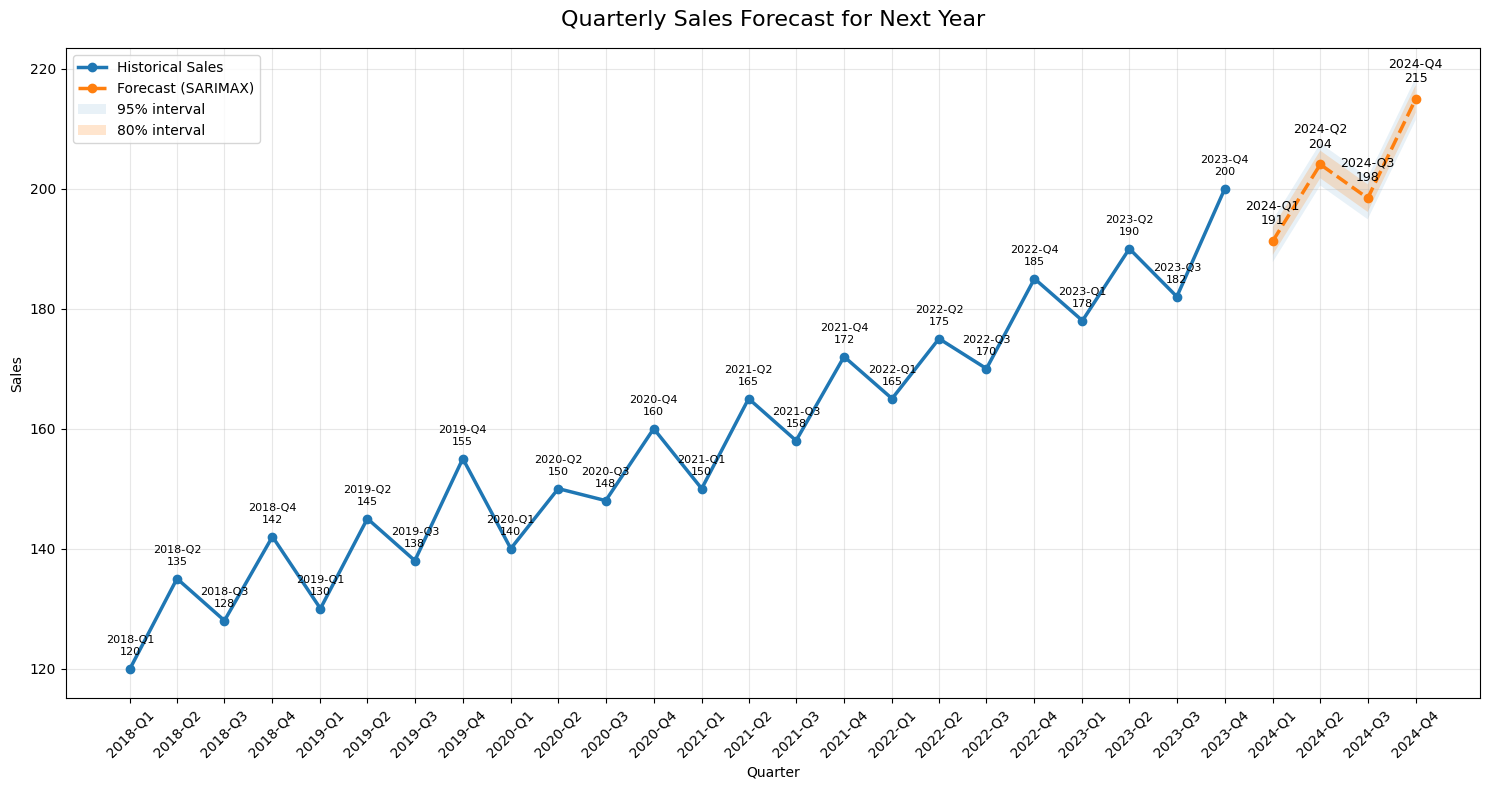

Saved chart to: quarterly_forecast_plot.png


In [7]:
# Plot history + forecast with quarter labels
plt.figure(figsize=(15, 8))

historical_dates = ts_df.index
historical_values = ts_df[TARGET_COLUMN_NAME].values

forecast_dates = pd.to_datetime(forecast_df["Date"])
forecast_values = forecast_df["Forecast"].values

# Build readable quarter labels like 2024-Q1
def quarter_label(dt):
    q = ((pd.Timestamp(dt).month - 1) // 3) + 1
    return f"{pd.Timestamp(dt).year}-Q{q}"

# historical line
plt.plot(
    historical_dates,
    historical_values,
    marker="o",
    linewidth=2.5,
    label="Historical Sales"
)

# forecast line
plt.plot(
    forecast_dates,
    forecast_values,
    marker="o",
    linestyle="--",
    linewidth=2.5,
    label=f"Forecast ({best_model_name})"
)

# confidence bands
plt.fill_between(
    forecast_dates,
    forecast_df["Lower_95"].values,
    forecast_df["Upper_95"].values,
    alpha=0.10,
    label="95% interval"
)

plt.fill_between(
    forecast_dates,
    forecast_df["Lower_80"].values,
    forecast_df["Upper_80"].values,
    alpha=0.20,
    label="80% interval"
)

# Annotate historical points with quarter + value
for x, y in zip(historical_dates, historical_values):
    plt.annotate(
        f"{quarter_label(x)}\n{y:,.0f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=8
    )

# Annotate forecast points with quarter + value
for x, y in zip(forecast_dates, forecast_values):
    plt.annotate(
        f"{quarter_label(x)}\n{y:,.0f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 12),
        ha="center",
        fontsize=9
    )

# Custom x-axis labels
all_dates = list(historical_dates) + list(forecast_dates)
all_labels = [quarter_label(d) for d in all_dates]
plt.xticks(all_dates, all_labels, rotation=45)

plt.title("Quarterly Sales Forecast for Next Year", fontsize=16, pad=16)
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(OUTPUT_PLOT_PNG, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved chart to: {OUTPUT_PLOT_PNG}")


In [8]:

# Friendly summary
print("Forecast summary:")
for _, row in forecast_df.iterrows():
    print(f"  {row['Quarter']}: {row['Forecast']:,.2f}")

print("\nModel comparison:")
display(comparison)


Forecast summary:
  2024-Q1: 191.28
  2024-Q2: 204.05
  2024-Q3: 198.42
  2024-Q4: 214.97

Model comparison:


,model,mae,rmse,best_order,best_seasonal_order
0,SARIMAX,3.706563,6.358207,"(0, 1, 1)","(0, 1, 1, 4)"
1,HistGradientBoostingRegressor,15.226671,17.599518,NaN,NaN



## Notes

- This notebook is designed for a **single quarterly sales time series**.
- If you later want stronger forecasting for multiple products, regions, or channels, the notebook can be extended to support grouped forecasting.
- The ML model uses lagged sales and quarter seasonality features, while SARIMAX explicitly models temporal autocorrelation and quarterly seasonality.
- For best results, use **at least 3 years** of quarterly history.
